In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import datetime as dt
from scipy import stats
import random
import statsmodels.api as sm
from numpy import array 
#from pandas.stats.api import ols
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
import statsmodels.formula.api as smf
from sklearn.metrics import auc
from sklearn.feature_selection import SelectKBest, chi2
pd.set_option('display.max_columns', 10000)
pd.set_option('display.max_rows', 10000)

In [3]:
DT_bank = pd.read_csv("/content/drive/MyDrive/RSM8502_Group_Asgmt/bank-additional-full.csv", sep =";")
#/content/drive/MyDrive/RSM8502_Group_Asgmt/bank-additional-full.csv
#https://colab.research.google.com/drive/14LZQhMORbXGyeXtKLaAGgRCk8MaPyUJD?usp=sharing
# /content/drive/MyDrive/RSM8502_Group_Asgmt/bank-additional-full.csv
#sentTrain = pd.read_csv('drive/MyDrive/COMP551_Project2/Sentiment140/training.1600000.processed.noemoticon.csv',header=None,encoding='latin-1')

In [4]:
DT_bank_original = DT_bank

## Correlation

In [5]:
# Correlations
corrM = DT_bank.corr()
corrM

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:5: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  """


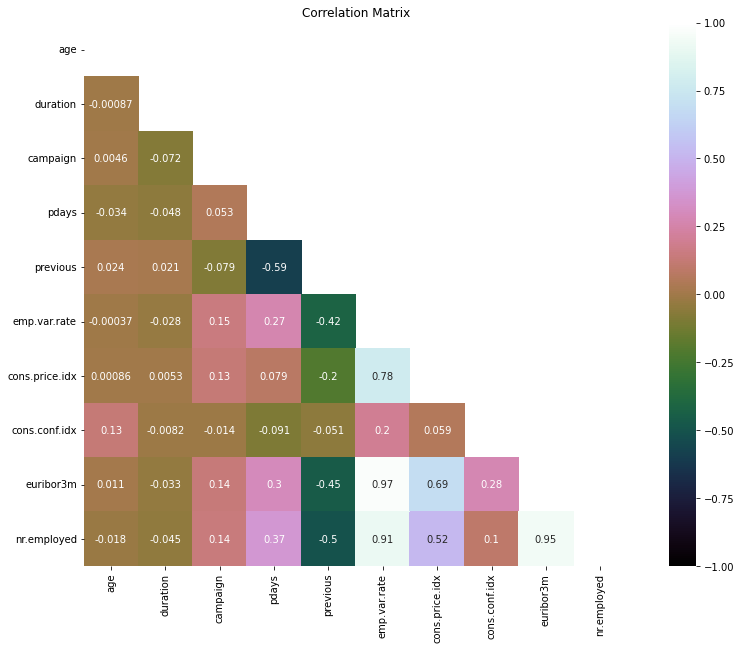

In [6]:
#Correlation plot
plt.figure(figsize = (15,10))
plt.title("Correlation Matrix")

mask = np.triu(np.ones_like(DT_bank.corr(), dtype=np.bool))
sns.heatmap(corrM, square = True, mask = mask, vmin=-1, vmax=1, annot = True, cmap = "cubehelix")

## Missing Values

In [7]:
DT_bank.shape

(41188, 21)

In [8]:
DT_bank.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [9]:
DT_bank.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [10]:
DT_bank_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

In [11]:
for i in range(len(DT_bank_columns)):
  val_i = DT_bank[DT_bank_columns[i]].value_counts()
  print(DT_bank_columns[i], "- column distribution:")
  print(val_i)
  print("\n")

job - column distribution:
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: job, dtype: int64


marital - column distribution:
married     24928
single      11568
divorced     4612
unknown        80
Name: marital, dtype: int64


education - column distribution:
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: education, dtype: int64


default - column distribution:
no         32588
unknown     8597
yes            3
Name: default, dtype: int64


housing - column distribution:
yes        21576
no         18622
unknown      990
Name: housing, dtype: int64


loan - column dis

In [12]:
DT_bank.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Continuous variables do not have a missing value. Based on the distribution of the categorical variables, it seems like the missing values are identified for columns: **job, marital, education, defalut, housing, loan**

In [13]:
DT_bank["loan"].unique()

array(['no', 'yes', 'unknown'], dtype=object)

In [14]:
DT_bank.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [15]:
DT_bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [16]:
# Get the values
# job_prop = job_prop.drop(index = "unknown")
# marital_prop = marital_prop.drop(index = "unknown")
# education_prop = education_prop.drop(index = "unknown")
# housing_prop = housing_prop.drop(index = "unknown")
# loan_prop = loan_prop.drop(index = "unknown")

job_dist = DT_bank[DT_bank["job"] != "unknown"]
job_prop = job_dist.job.value_counts(normalize = True)

marital_dist = DT_bank[DT_bank["marital"] != "unknown"]
marital_prop = marital_dist.marital.value_counts(normalize = True)

education_dist = DT_bank[DT_bank["education"] != "unknown"]
education_prop = education_dist.education.value_counts(normalize = True)
#default_prop = DT_bank.default.value_counts(normalize = True)

housing_dist = DT_bank[DT_bank["housing"] != "unknown"]
housing_prop = housing_dist.housing.value_counts(normalize = True) 

loan_dist = DT_bank[DT_bank["loan"] != "unknown"]
loan_prop = loan_dist.loan.value_counts(normalize = True)


In [17]:
# job_list = dict(zip(job_prop.job, job_prop.proportion))
# marital_list = dict(zip(marital_prop.marital, marital_prop.proportion))
# education_list = dict(zip(education_prop.education, education_prop.proportion))
# default_list = dict(zip(default_prop.default, default_prop.proportion))
# housing_list = dict(zip(housing_prop.housing, housing_prop.proportion))
# loan_list = dict(zip(loan_prop.loan, loan_prop.proportion))

DT_bank["job_imp"] = DT_bank["job"]
job_missing = DT_bank["job_imp"]=="unknown"
DT_bank.loc[job_missing,'job_imp'] = np.random.choice(job_prop.index, size=len(DT_bank[job_missing]),p=job_prop.values)

DT_bank["marital_imp"] = DT_bank["marital"]
marital_missing = DT_bank["marital_imp"]=="unknown"
DT_bank.loc[marital_missing,'marital_imp'] = np.random.choice(marital_prop.index, size=len(DT_bank[marital_missing]),p=marital_prop.values)

DT_bank["education_imp"] = DT_bank["education"]
education_missing = DT_bank["education_imp"]=="unknown"
DT_bank.loc[education_missing,'education_imp'] = np.random.choice(education_prop.index, size=len(DT_bank[education_missing]),p=education_prop.values)

DT_bank["housing_imp"] = DT_bank["housing"]
housing_missing = DT_bank["housing_imp"]=="unknown"
DT_bank.loc[housing_missing,'housing_imp'] = np.random.choice(housing_prop.index, size=len(DT_bank[housing_missing]),p=housing_prop.values)

DT_bank["loan_imp"] = DT_bank["loan"]
loan_missing = DT_bank["loan_imp"]=="unknown"
DT_bank.loc[loan_missing,'loan_imp'] = np.random.choice(loan_prop.index, size=len(DT_bank[loan_missing]),p=loan_prop.values)


In [18]:
DT_bank[DT_bank["housing"] == "unknown"].head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_imp,marital_imp,education_imp,housing_imp,loan_imp
29,55,unknown,married,university.degree,unknown,unknown,unknown,telephone,may,mon,362,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,technician,married,university.degree,yes,no
81,51,blue-collar,married,basic.4y,unknown,unknown,unknown,telephone,may,mon,212,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,blue-collar,married,basic.4y,no,no
261,27,blue-collar,single,basic.6y,no,unknown,unknown,telephone,may,mon,119,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,blue-collar,single,basic.6y,no,yes
385,59,management,married,basic.4y,unknown,unknown,unknown,telephone,may,tue,437,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,management,married,basic.4y,yes,no
401,48,services,married,high.school,unknown,unknown,unknown,telephone,may,tue,152,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,services,married,high.school,no,no


In [19]:
#Random filling the unknown values in the missing columns

#for i in DT_bank.index():
  #DT_bank.at[i,'job_imp'] = random.choices(job_list, k=len(DT_bank)) if DT_bank.loc[i,'job'] == "unknown" else DT_bank[i,"job"]
# DT_bank["job_imp"] = DT_bank['job'].apply(lambda x: np.random.choice(job_prop.index, size=len(DT_bank[job_missing]),p=job_prop.values) if x == "unknown" else x)
#DT_bank['job_imp'] = DT_bank['job_imp'].str.replace(r"\[","")

# DT_bank["marital_imp"] = DT_bank['marital'].apply(lambda x: random.choices(marital_list, weights = marital_weights) if x == "unknown" else x)
# DT_bank['marital_imp'] = DT_bank['marital_imp'].str.replace(r"\[","")

# DT_bank["education_imp"] = DT_bank['education'].apply(lambda x: random.choices(education_list, weights = education_weights) if x == "unknown" else x)
# DT_bank['education_imp'] = DT_bank['education_imp'].str.replace(r"\[","")

# DT_bank["default_imp"] = DT_bank['default'].apply(lambda x: random.choices(default_list, weights = default_weights) if x == "unknown" else x)
# DT_bank['default_imp'] = DT_bank['default_imp'].str.replace(r"\[","")

# DT_bank["housing_imp"] = DT_bank['housing'].apply(lambda x: random.choices(housing_list, weights = housing_weights) if x == "unknown" else x)
# DT_bank['housing_imp'] = DT_bank['housing_imp'].str.replace(r"\[","")

# DT_bank["loan_imp"] = DT_bank['loan'].apply(lambda x: random.choices(loan_list, weights = loan_weights) if x == "unknown" else x)
# DT_bank['loan_imp'] = DT_bank['loan_imp'].str.replace(r"\[","")


In [20]:
DT_bank["job_imp"].value_counts(normalize = True)

admin.           0.254977
blue-collar      0.226862
technician       0.165097
services         0.096921
management       0.071550
retired          0.042075
entrepreneur     0.035690
self-employed    0.034743
housemaid        0.025906
unemployed       0.024764
student          0.021414
Name: job_imp, dtype: float64

In [21]:
DT_bank["job"].value_counts(normalize = True)

admin.           0.253035
blue-collar      0.224677
technician       0.163713
services         0.096363
management       0.070992
retired          0.041760
entrepreneur     0.035350
self-employed    0.034500
housemaid        0.025736
unemployed       0.024619
student          0.021244
unknown          0.008012
Name: job, dtype: float64

In [22]:
DT_bank.housing_imp.value_counts()

yes    22109
no     19079
Name: housing_imp, dtype: int64

In [23]:
DT_bank.housing.value_counts()

yes        21576
no         18622
unknown      990
Name: housing, dtype: int64

In [24]:
# Fitting a linear model

# n_row = len(DT_bank)
# for i in nrow:
#   linmodel_job = ols(y = DT_bank['job'], x = DT_bank[['age', 'marital_imp', 'education_imp', 'default_imp', 'housing_imp',
#        'loan_imp', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
#        'previous', 'poutcome']])
#   predict_job = np.random.normal(,predict(linmodel_job),)

In [25]:
DT_bank[DT_bank["housing"]=="unknown"][['housing_imp','housing']].head(50) 

,housing_imp,housing
29,yes,unknown
81,no,unknown
261,no,unknown
385,yes,unknown
401,no,unknown
470,no,unknown
485,yes,unknown
494,yes,unknown
495,yes,unknown
501,yes,unknown


In [26]:
DT_bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_imp,marital_imp,education_imp,housing_imp,loan_imp
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,housemaid,married,basic.4y,no,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,services,married,high.school,no,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,services,married,high.school,yes,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,admin.,married,basic.6y,no,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,services,married,high.school,no,yes


## Cross tabulation

In [27]:
DT_bank.columns
DT_bank_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'poutcome']

job  admin.  blue-collar  entrepreneur  housemaid  management  retired  \
y                                                                        
no     9070         8616          1332        954        2596     1286   
yes    1352          638           124        106         328      434   
All   10422         9254          1456       1060        2924     1720   

job  self-employed  services  student  technician  unemployed  unknown    All  
y                                                                              
no            1272      3646      600        6013         870      293  36548  
yes            149       323      275         730         144       37   4640  
All           1421      3969      875        6743        1014      330  41188   

Chi2 value= 961.2424403289554
p-value= 1.5051039635440898e-187
Degrees of freedom= 24

marital  divorced  married  single  unknown    All
y                                                 
no           4136    22396    9948    

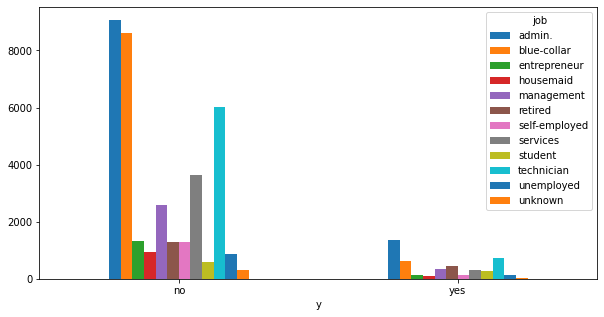

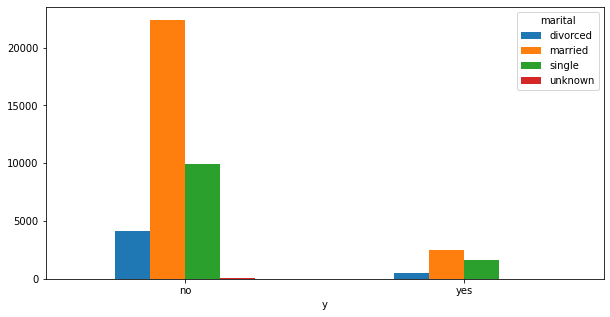

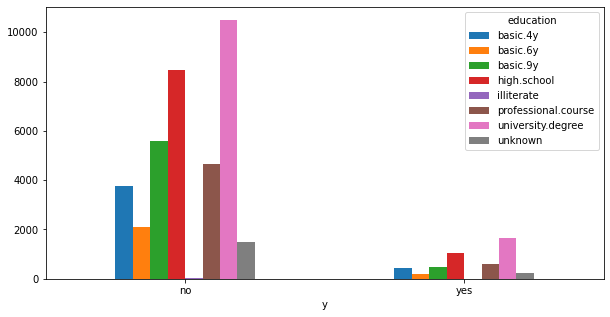

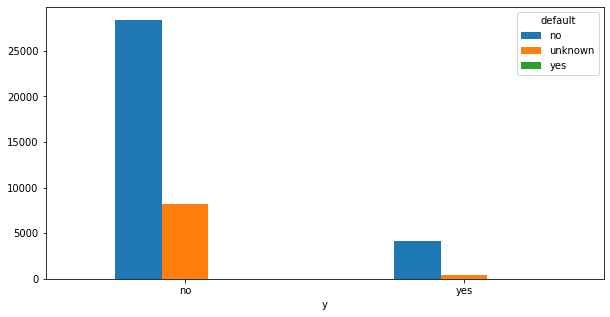

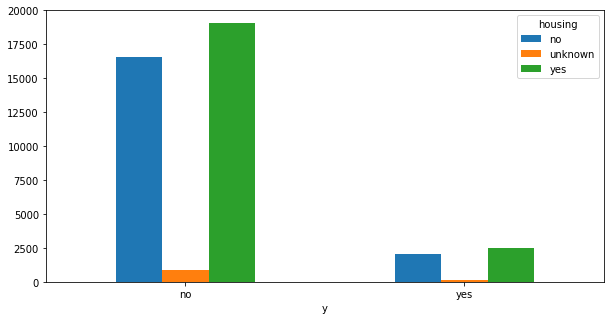

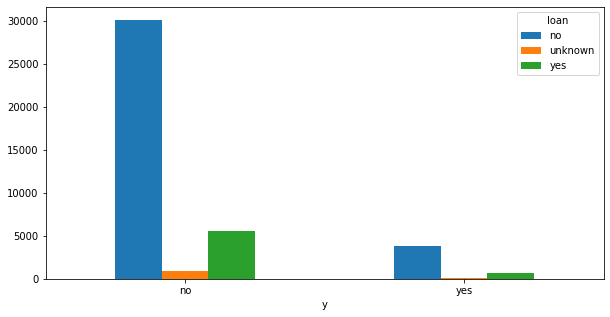

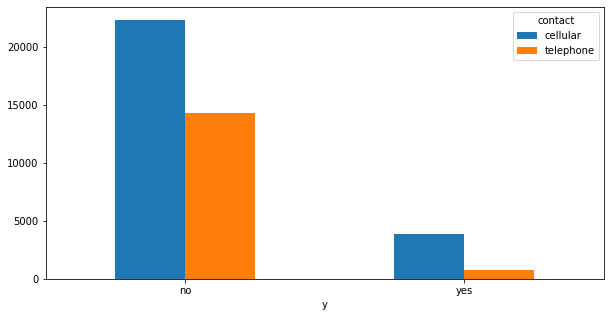

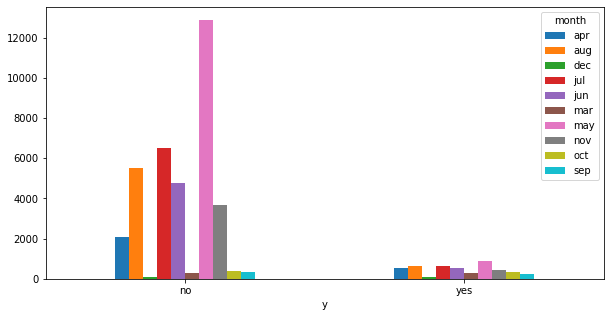

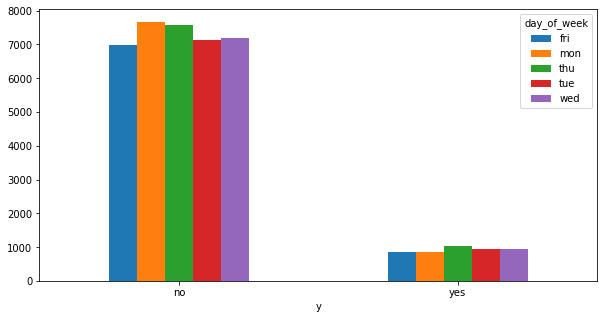

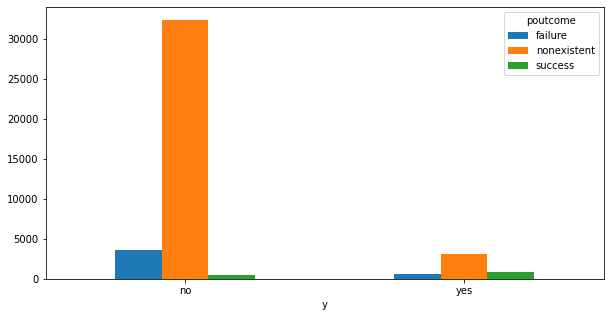

In [28]:
# Cross tab analysis using columns with unknown
for x in DT_bank_columns:
  nl = "\n"

  crosstab = pd.crosstab(DT_bank["y"], DT_bank[x], margins = True)
  crosstab_plot = pd.crosstab(DT_bank["y"], DT_bank[x])
  crosstab_plot.plot(kind="bar", rot=0, figsize = (10,5))
  print(crosstab, nl)
  chi2, p, dof, expected = stats.chi2_contingency(crosstab)
  print(f"Chi2 value= {chi2}{nl}p-value= {p}{nl}Degrees of freedom= {dof}{nl}")

job_imp  admin.  blue-collar  entrepreneur  housemaid  management  retired  \
y                                                                            
no         9141         8696          1345        961        2613     1298   
yes        1361          648           125        106         334      435   
All       10502         9344          1470       1067        2947     1733   

job_imp  self-employed  services  student  technician  unemployed    All  
y                                                                         
no                1281      3667      606        6064         876  36548  
yes                150       325      276         736         144   4640  
All               1431      3992      882        6800        1020  41188   

Chi2 value= 953.79462348782
p-value= 1.317645099574035e-187
Degrees of freedom= 22

marital_imp  divorced  married  single    All
y                                            
no               4143    22434    9971  36548
yes       

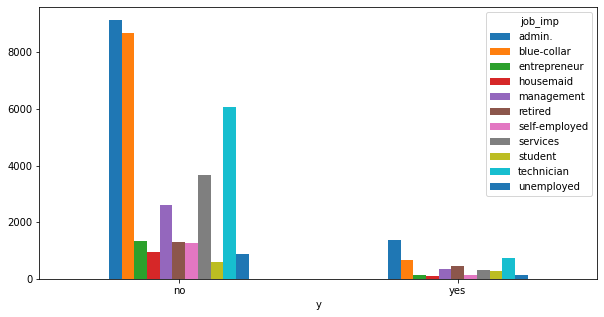

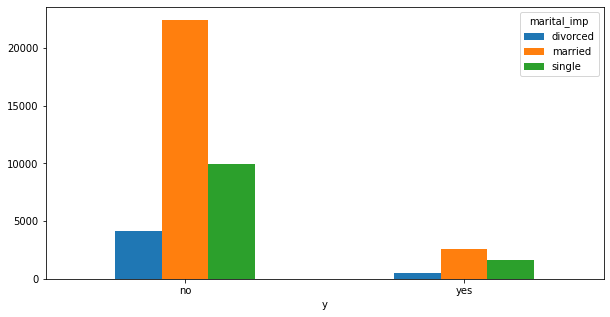

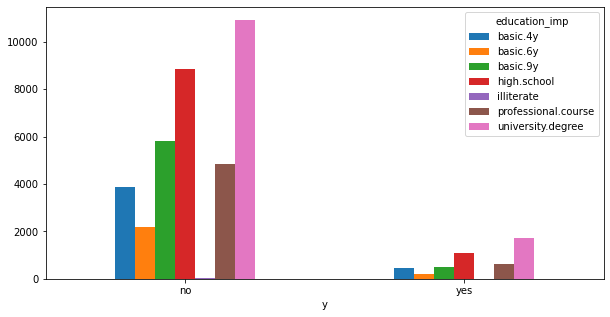

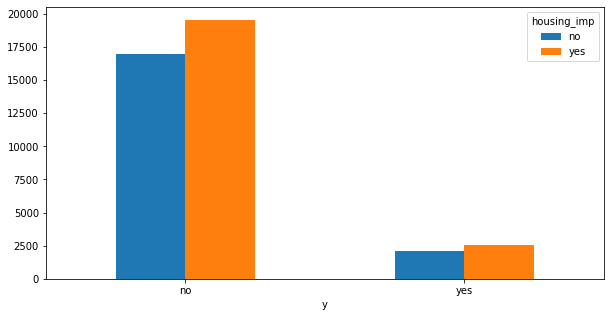

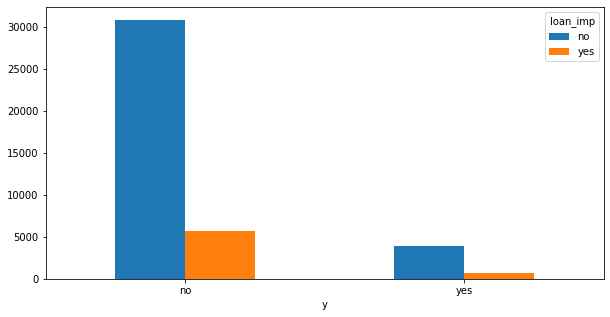

In [29]:
# Cross tab analysis using columns after missing value treatment
DT_bank_columns_imputed = ['job_imp', 'marital_imp', 'education_imp', 'housing_imp', 'loan_imp']

for x in DT_bank_columns_imputed:
  nl = "\n"

  crosstab = pd.crosstab(DT_bank["y"], DT_bank[x], margins = True)
  crosstab_plot = pd.crosstab(DT_bank["y"], DT_bank[x])
  crosstab_plot.plot(kind="bar", rot=0, figsize = (10,5))
  print(crosstab, nl)
  chi2, p, dof, expected = stats.chi2_contingency(crosstab)
  print(f"Chi2 value= {chi2}{nl}p-value= {p}{nl}Degrees of freedom= {dof}{nl}")

## Predictive Modelling

In [30]:
DT_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [31]:
DT_bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'job_imp',
       'marital_imp', 'education_imp', 'housing_imp', 'loan_imp'],
      dtype='object')

In [32]:
# Create the new columns and introduce transformations
for row in range(len(DT_bank)):
  if DT_bank.loc[row, "pdays"] == "999":
    DT_bank["dummy_pdays"] = "0"
  else:
    DT_bank["dummy_pdays"] = "1"

In [33]:
# Create the new column called poutcome and month
# for row in range(len(DT_bank)):
#   DT_bank["poutcome_month"] = DT_bank.loc[row, "poutcome"] * DT_bank.loc[row, "month"]

In [34]:
DT_bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'job_imp',
       'marital_imp', 'education_imp', 'housing_imp', 'loan_imp',
       'dummy_pdays'],
      dtype='object')

In [35]:
DT_bank_model = DT_bank.drop(columns = ['job', 'marital', 'education', 'housing', 'loan','emp.var.rate', 'cons.price.idx', 
       'cons.conf.idx', 'euribor3m', 'nr.employed'])

In [36]:
#DT_bank_model[(DT_bank_model.housing_imp=="1") and (DT_bank_model.loan_imp =="1")]['housing_imp','loan_imp','default_imp'].head()
#DT_bank_model.loc[(DT_bank_model.housing_imp == "1") & (DT_bank_model.loan_imp == "1")]

In [37]:
# creating a unique id column in dataframe
#DT_bank_model['client_id'] = range(1, 1+len(DT_bank_model))
#DT_bank_model = DT_bank_model.drop(columns = ['client_id'])

In [38]:
LE = LabelEncoder()
DT_bank_model['contact'] = LE.fit_transform(DT_bank_model['contact'])
DT_bank_model['month'] = LE.fit_transform(DT_bank_model['month'])
DT_bank_model['day_of_week'] = LE.fit_transform(DT_bank_model['day_of_week'])
DT_bank_model['job_imp'] = LE.fit_transform(DT_bank_model['job_imp'])
DT_bank_model['marital_imp'] = LE.fit_transform(DT_bank_model['marital_imp'])
DT_bank_model['education_imp'] = LE.fit_transform(DT_bank_model['education_imp'])
DT_bank_model['default'] = LE.fit_transform(DT_bank_model['default'])
DT_bank_model['housing_imp'] = LE.fit_transform(DT_bank_model['housing_imp'])
DT_bank_model['loan_imp'] = LE.fit_transform(DT_bank_model['loan_imp'])
DT_bank_model['poutcome'] = LE.fit_transform(DT_bank_model['poutcome'])
DT_bank_model['pdays'] = LE.fit_transform(DT_bank_model['pdays'])
DT_bank_model['dummy_pdays'] = LE.fit_transform(DT_bank_model['dummy_pdays'])
DT_bank_model['y'] = LE.fit_transform(DT_bank_model['y'])


In [39]:
DT_bank_model.head()

,age,default,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y,job_imp,marital_imp,education_imp,housing_imp,loan_imp,dummy_pdays
0,56,0,1,6,1,261,1,26,0,1,0,3,1,0,0,0,0
1,57,1,1,6,1,149,1,26,0,1,0,7,1,3,0,0,0
2,37,0,1,6,1,226,1,26,0,1,0,7,1,3,1,0,0
3,40,0,1,6,1,151,1,26,0,1,0,0,1,1,0,0,0
4,56,0,1,6,1,307,1,26,0,1,0,7,1,3,0,1,0


### Using duration:

In [40]:
# Define the independent and dependent variables - using duration variable in modelling
y_dur= DT_bank_model['y'] #dependent variable is Decision
X_dur= DT_bank_model.drop(['y'], axis=1)

print("Feature dimensions before selection",X_dur.shape)

Feature dimensions before selection (41188, 16)


In [47]:
#Selecting required features based on chi square test
KBest_dur = SelectKBest(chi2).fit(X_dur, y_dur)

f_dur = KBest_dur.get_support(1)
X_new_dur = X_dur[X_dur.columns[f_dur]]
print("Final selected features:", X_new_dur.columns)

# select = SelectKBest(score_func=chi2)
# z = select.fit_transform(X_dur,y_dur)

# filter = select.get_support()
# X_new_dur = X_dur[X_dur.columns[z]]
# X_new_dur.columns

Final selected features: Index(['age', 'default', 'contact', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'job_imp', 'education_imp'],
      dtype='object')


In [48]:
# splitting the data
X_train_dur, X_test_dur, y_train_dur, y_test_dur = train_test_split(X_new_dur, y_dur, test_size = 0.2, random_state = 10)

# define min max scaler
scaler_dur = MinMaxScaler()

# transform data
X_train_dur = scaler_dur.fit_transform(X_train_dur)
X_test_dur = scaler_dur.transform(X_test_dur)

#Logistic classifier
classifier_dur = LogisticRegression(random_state = 10)
classifier_dur.fit(X_train_dur, y_train_dur)

LogisticRegression(random_state=10)

In [49]:
#Predict and get accuracy for test data

y_pred_dur = classifier_dur.predict(X_test_dur)
test_acc_dur = accuracy_score(y_test_dur, y_pred_dur)
print("The Accuracy for Test Set is {}".format(test_acc_dur*100))

The Accuracy for Test Set is 89.98543335761107


Text(0.5, 33.0, 'Predicted Values')

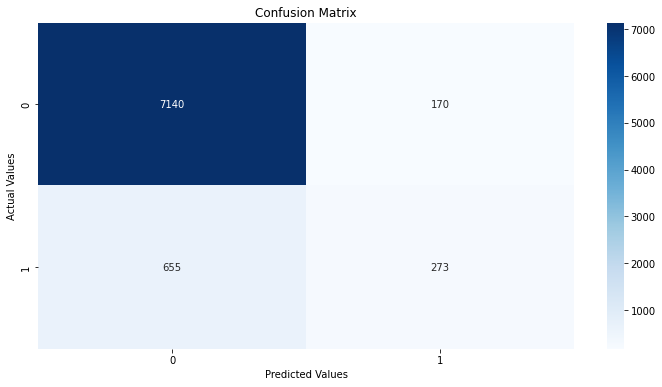

In [50]:
cm_dur=confusion_matrix(y_test_dur,y_pred_dur)
plt.figure(figsize=(12,6))
plt.title("Confusion Matrix")
sns.heatmap(cm_dur, annot=True,fmt="d", cmap="Blues")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")

### Without using duration:

In [51]:
group_1 = ('age', 'job', 'marital', 'education', 'default', 'housing', 'loan')
group_2 = ('contact', 'month', 'day_of_week', 'duration')
group_3 = ('campaign', 'pdays', 'previous', 'poutcome')

In [52]:
# Define the independent and dependent variables - using duration variable in modelling
y= DT_bank_model['y'] #dependent variable is Decision
X= DT_bank_model.drop(['y','duration'], axis=1)

print("Feature dimensions before selection",X.shape)

Feature dimensions before selection (41188, 15)


In [53]:
#Selecting required features based on chi square test
KBest = SelectKBest(chi2).fit(X, y)

f = KBest.get_support(1)
X_new = X[X.columns[f]]
print("Final selected features:", X_new.columns)

Final selected features: Index(['age', 'default', 'contact', 'campaign', 'pdays', 'previous',
       'poutcome', 'job_imp', 'marital_imp', 'education_imp'],
      dtype='object')


In [54]:
KBest.scores_

array([1.03274145e+02, 3.21922903e+02, 5.47958309e+02, 1.92728404e+00,
       1.02314446e+01, 5.41971889e+02, 2.46667290e+03, 3.09017243e+03,
       9.82311743e+01, 9.10112457e+01, 2.69714251e+01, 1.29139765e+02,
       2.70566935e+00, 3.56310360e-01,            nan])

In [55]:
# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

# define min max scaler
scaler = MinMaxScaler()

# transform data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Logistic classifier
classifier = LogisticRegression(random_state = 10)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=10)

In [56]:
print("Training set score: {:.3f}".format(classifier.score(X_train,y_train)))
print("Test set score: {:.3f}".format(classifier.score(X_test,y_test)))

Training set score: 0.898
Test set score: 0.895


In [57]:
#Accuracy for train
y_pred_train = classifier.predict(X_train)
train_acc = accuracy_score(y_train, y_pred_train)
print("The Accuracy for train Set is {}".format(train_acc*100))

The Accuracy for train Set is 89.79969650986342


In [58]:
#Accuracy for test
y_pred_test = classifier.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)
print("The Accuracy for test Set is {}".format(test_acc*100))

The Accuracy for test Set is 89.4634620053411


Text(0.5, 33.0, 'Predicted Values')

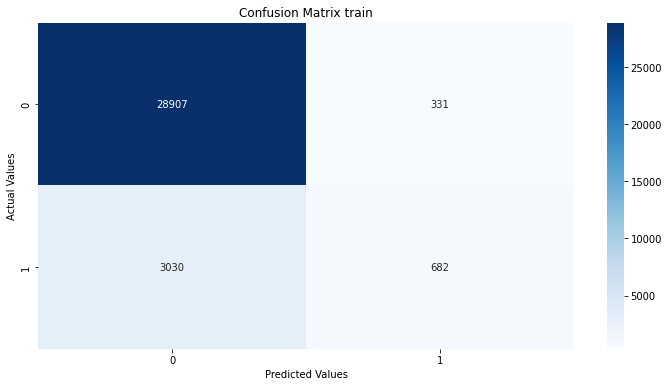

In [59]:
#CM for train
cm_train=confusion_matrix(y_train,y_pred_train)
plt.figure(figsize=(12,6))
plt.title("Confusion Matrix train")
sns.heatmap(cm_train, annot=True,fmt="d", cmap="Blues")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")

In [60]:
#CM for train
total_train = sum(sum(cm_train))
Accuracy_train = (cm_train[0,0]+cm_train[1,1])/total_train
Specificity_train = cm_train[0,0]/(cm_train[0,0]+cm_train[0,1])
Sensitivity_train= cm_train[1,1]/(cm_train[1,0]+cm_train[1,1])

print("Accuracy:",Accuracy_train)
print("Specificity:",Specificity_train)
print("Sensitivity:",Sensitivity_train)

Accuracy: 0.8979969650986342
Specificity: 0.9886791162186196
Sensitivity: 0.18372844827586207


Text(0.5, 33.0, 'Predicted Values')

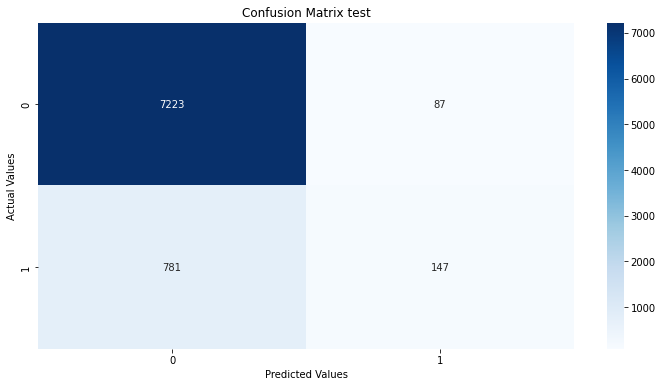

In [61]:
cm_test=confusion_matrix(y_test,y_pred_test)
plt.figure(figsize=(12,6))
plt.title("Confusion Matrix test")
sns.heatmap(cm_test, annot=True,fmt="d", cmap="Blues")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")

In [62]:
#CM for test
total_test = sum(sum(cm_test))
Accuracy_test = (cm_test[0,0]+cm_test[1,1])/total_test
Specificity_test = cm_test[0,0]/(cm_test[0,0]+cm_test[0,1])
Sensitivity_test = cm_test[1,1]/(cm_test[1,0]+cm_test[1,1])

print("Accuracy:",Accuracy_test)
print("Specificity:",Specificity_test)
print("Sensitivity:",Sensitivity_test)

Accuracy: 0.894634620053411
Specificity: 0.9880984952120383
Sensitivity: 0.1584051724137931


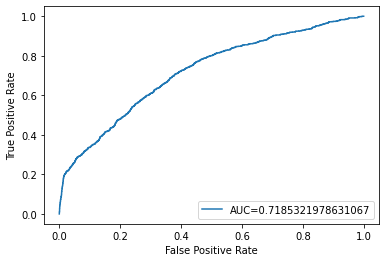

[1.86446101 0.86446101 0.85944915 ... 0.01526929 0.01519106 0.00350239]


In [63]:
# ROC Curve and AUC for logistic test

y_pred_proba = classifier.predict_proba(X_test)[::,1]
fpr, tpr, thresholds = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

#Plot the ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()
print(thresholds)

In [64]:
def Find_Optimal_Cutoff(target, predicted):
    fpr, tpr, threshold = metrics.roc_curve(target, predicted)
    i = np.arange(len(tpr)) 
    roc = pd.DataFrame({'tf' : pd.Series(tpr-(1-fpr), index=i), 'threshold' : pd.Series(threshold, index=i)})
    roc_t = roc.iloc[(roc.tf-0).abs().argsort()[:1]]

    return list(roc_t['threshold']) 

threshold_test = Find_Optimal_Cutoff(y_test,  y_pred_proba)
threshold_test

[0.11625075042118146]

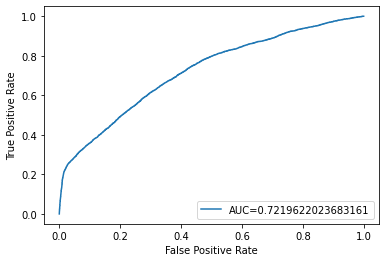

In [65]:
# ROC Curve and AUC for logistic train
y_pred_proba_train = classifier.predict_proba(X_train)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_train,  y_pred_proba_train)
auc = metrics.roc_auc_score(y_train, y_pred_proba_train)

#Plot the ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

In [66]:
threshold_train = Find_Optimal_Cutoff(y_train,  y_pred_proba_train)
threshold_train

[0.1158958293321836]

In [ ]:
# Precision Recall curve in logistic

# precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
# f1, auc_pr = f1_score(y_test, y_pred), auc(recall, precision)

# # summarize scores
# print('Logistic: f1=%.3f auc=%.3f' % (f1, auc_pr))

# # plot the precision-recall curves
# plt.plot(recall, precision, marker='.', label="AUC="+str(auc_pr))
# # axis labels
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# # show the legend
# plt.legend()
# plt.show()

In [ ]:
#Classification Report 
# print(classification_report(y_test, y_pred))

In [ ]:
#Classification Report 
# print(classification_report(y_train, y_pred))

#### Understand the significance of the variables used for prediction

In [67]:
ytrain = DT_bank_model[["y"]]
xtrain = DT_bank_model[['age', 'default', 'contact', 'day_of_week', 'campaign',
       'previous', 'poutcome', 'job_imp', 'marital_imp', 'education_imp',
       'housing_imp', 'loan_imp','month','duration']]
form = 'y~ age+default+contact+day_of_week+campaign+previous+poutcome+job_imp+marital_imp+education_imp+housing_imp+loan_imp+month+pdays+poutcome:month'
log_reg = smf.mnlogit(formula = form, 
                   data = DT_bank_model).fit()

Optimization terminated successfully.
         Current function value: 0.308209
         Iterations 7


In [68]:
# printing the summary table - using the duration variable
print(log_reg.summary())

                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                41188
Model:                        MNLogit   Df Residuals:                    41172
Method:                           MLE   Df Model:                           15
Date:                Wed, 14 Sep 2022   Pseudo R-squ.:                  0.1245
Time:                        03:49:39   Log-Likelihood:                -12695.
converged:                       True   LL-Null:                       -14499.
Covariance Type:            nonrobust   LLR p-value:                     0.000
           y=1       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.0983      0.284     -3.863      0.000      -1.656      -0.541
age                0.0158      0.002      9.514      0.000       0.013       0.019
default           -0.7146      0.054

In [69]:
ytest = DT_bank_model[["y"]]
xtest = DT_bank_model[['age', 'default', 'contact', 'day_of_week', 'campaign',
       'previous', 'poutcome', 'job_imp', 'marital_imp', 'education_imp',
       'housing_imp', 'loan_imp','month','pdays']]
import statsmodels.api as sm
log_reg = sm.Logit(ytest, xtest).fit()

Optimization terminated successfully.
         Current function value: 0.308578
         Iterations 7


## Predictive Modelling - Using the group 4 variables (sensitivity analysis)

In [70]:
DT_bank_model_2 = DT_bank.drop(columns = ['job', 'marital', 'education', 'housing', 'loan', 'cons.price.idx',  'euribor3m', 'nr.employed'])

In [69]:
#DT_bank_model[(DT_bank_model.housing_imp=="1") and (DT_bank_model.loan_imp =="1")]['housing_imp','loan_imp','default_imp'].head()
#DT_bank_model.loc[(DT_bank_model.housing_imp == "1") & (DT_bank_model.loan_imp == "1")]

In [70]:
# creating a unique id column in dataframe
#DT_bank_model['client_id'] = range(1, 1+len(DT_bank_model))
#DT_bank_model = DT_bank_model.drop(columns = ['client_id'])   'emp.var.rate','cons.conf.idx'

In [71]:
LE = LabelEncoder()
DT_bank_model_2['contact'] = LE.fit_transform(DT_bank_model_2['contact'])
DT_bank_model_2['month'] = LE.fit_transform(DT_bank_model_2['month'])
DT_bank_model_2['day_of_week'] = LE.fit_transform(DT_bank_model_2['day_of_week'])
DT_bank_model_2['job_imp'] = LE.fit_transform(DT_bank_model_2['job_imp'])
DT_bank_model_2['marital_imp'] = LE.fit_transform(DT_bank_model_2['marital_imp'])
DT_bank_model_2['education_imp'] = LE.fit_transform(DT_bank_model_2['education_imp'])
DT_bank_model_2['default'] = LE.fit_transform(DT_bank_model_2['default'])
DT_bank_model_2['housing_imp'] = LE.fit_transform(DT_bank_model_2['housing_imp'])
DT_bank_model_2['loan_imp'] = LE.fit_transform(DT_bank_model_2['loan_imp'])
DT_bank_model_2['poutcome'] = LE.fit_transform(DT_bank_model_2['poutcome'])
DT_bank_model_2['dummy_pdays'] = LE.fit_transform(DT_bank_model_2['dummy_pdays'])
DT_bank_model_2['pdays'] = LE.fit_transform(DT_bank_model_2['pdays'])
DT_bank_model_2['emp.var.rate'] = LE.fit_transform(DT_bank_model_2['emp.var.rate'])
DT_bank_model_2['cons.conf.idx'] = LE.fit_transform(DT_bank_model_2['cons.conf.idx'])
DT_bank_model_2['y'] = LE.fit_transform(DT_bank_model_2['y'])

In [72]:
# Define the independent and dependent variables - using duration variable in modelling
y2 = DT_bank_model_2['y'] #dependent variable is Decision
X2 = DT_bank_model_2.drop(['y','duration'], axis=1)

print("Feature dimensions before selection",X2.shape)

Feature dimensions before selection (41188, 17)


In [73]:
#Selecting required features based on chi square test
KBest = SelectKBest(chi2).fit(X2, y2)

f = KBest.get_support(1)
X2_new = X2[X2.columns[f]]
print("Final selected features:", X2_new.columns)

Final selected features: Index(['age', 'default', 'contact', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.conf.idx', 'education_imp'],
      dtype='object')


In [76]:
# splitting the data
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_new, y2, test_size = 0.2, random_state = 10)

# define min max scaler
scaler = MinMaxScaler()

# transform data
X2_train = scaler.fit_transform(X2_train)
X2_test = scaler.transform(X2_test)

#Logistic classifier
classifier = LogisticRegression(random_state = 10)
classifier.fit(X2_train, y2_train)

LogisticRegression(random_state=10)

In [77]:
#Accuracy for train
y2_pred_train = classifier.predict(X2_train)
train_acc2 = accuracy_score(y2_train, y2_pred_train)
print("The Accuracy for train Set is {}".format(train_acc2*100))

The Accuracy for train Set is 89.81183611532624


In [78]:
#Accuracy for test
y2_pred_test = classifier.predict(X2_test)
test_acc2 = accuracy_score(y2_test, y2_pred_test)
print("The Accuracy for test Set is {}".format(test_acc2*100))

The Accuracy for test Set is 89.43918426802622


Text(0.5, 33.0, 'Predicted Values')

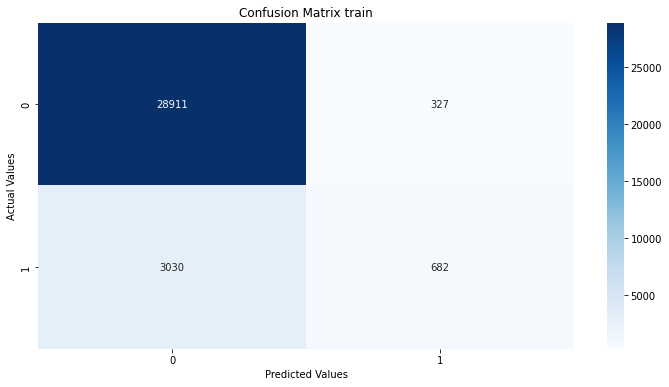

In [79]:
#CM for train
cm2_train=confusion_matrix(y2_train,y2_pred_train)
plt.figure(figsize=(12,6))
plt.title("Confusion Matrix train")
sns.heatmap(cm2_train, annot=True,fmt="d", cmap="Blues")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")

In [80]:
#CM for train
total_train2 = sum(sum(cm2_train))
Accuracy_train2 = (cm2_train[0,0]+cm2_train[1,1])/total_train2
Specificity_train2 = cm2_train[0,0]/(cm2_train[0,0]+cm2_train[0,1])
Sensitivity_train2 = cm2_train[1,1]/(cm2_train[1,0]+cm2_train[1,1])

print("Accuracy:",Accuracy_train2)
print("Specificity:",Specificity_train2)
print("Sensitivity:",Sensitivity_train2)

Accuracy: 0.8981183611532625
Specificity: 0.9888159244818387
Sensitivity: 0.18372844827586207


Text(0.5, 33.0, 'Predicted Values')

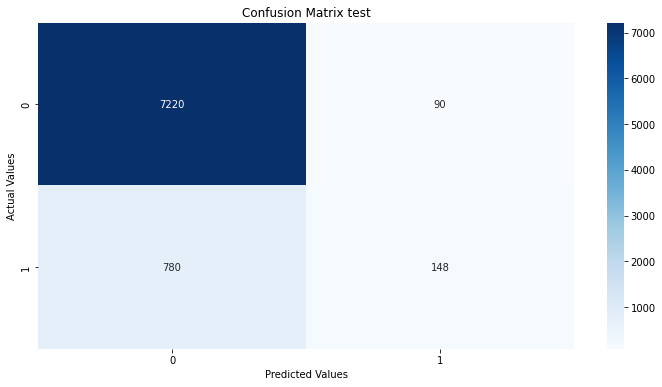

In [81]:
cm2_test=confusion_matrix(y2_test,y2_pred_test)
plt.figure(figsize=(12,6))
plt.title("Confusion Matrix test")
sns.heatmap(cm2_test, annot=True,fmt="d", cmap="Blues")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")

In [82]:
#CM for test
total_test2 = sum(sum(cm2_test))
Accuracy_test2 = (cm2_test[0,0]+cm2_test[1,1])/total_test2
Specificity_test2 = cm2_test[0,0]/(cm2_test[0,0]+cm2_test[0,1])
Sensitivity_test2 = cm2_test[1,1]/(cm2_test[1,0]+cm2_test[1,1])

print("Accuracy:",Accuracy_test2)
print("Specificity:",Specificity_test2)
print("Sensitivity:",Sensitivity_test2)

Accuracy: 0.8943918426802622
Specificity: 0.987688098495212
Sensitivity: 0.15948275862068967


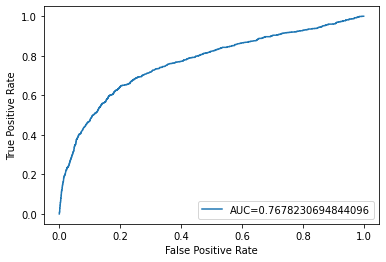

In [83]:
# ROC Curve and AUC for logistic test

y2_pred_proba = classifier.predict_proba(X2_test)[::,1]
fpr2, tpr2, _ = metrics.roc_curve(y2_test,  y2_pred_proba)
auc2 = metrics.roc_auc_score(y2_test, y2_pred_proba)

#Plot the ROC curve
plt.plot(fpr2,tpr2,label="AUC="+str(auc2))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

In [84]:
threshold_test2 = Find_Optimal_Cutoff(y2_test,  y2_pred_proba)
threshold_test2

[0.09417060430712589]

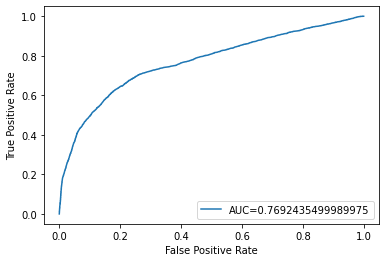

In [85]:
# ROC Curve and AUC for logistic train
y2_pred_proba_train = classifier.predict_proba(X2_train)[::,1]
fpr2t, tpr2t, _ = metrics.roc_curve(y2_train,  y2_pred_proba_train)
auc2t = metrics.roc_auc_score(y2_train, y2_pred_proba_train)

#Plot the ROC curve
plt.plot(fpr2t,tpr2t,label="AUC="+str(auc2t))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

In [86]:
threshold_train2 = Find_Optimal_Cutoff(y2_train,  y2_pred_proba_train)
threshold_train2

[0.09417060430712589]

In [87]:
ytest2 = DT_bank_model_2[["y"]]
xtest2 = DT_bank_model_2[['age', 'default', 'contact', 'day_of_week', 'campaign',
       'previous', 'poutcome', 'job_imp', 'marital_imp', 'education_imp',
       'housing_imp', 'loan_imp','month','emp.var.rate','cons.conf.idx','pdays']]
DT_bank_model_2_logit = DT_bank_model_2
DT_bank_model_2_logit.rename({'cons.conf.idx': 'cons_conf_idx', 'emp.var.rate': 'emp_var_rate'}, axis=1, inplace =True)
form2 = 'y~ age+default+contact+day_of_week+campaign+previous+poutcome+job_imp+marital_imp+education_imp+housing_imp+cons_conf_idx+emp_var_rate+loan_imp+month+pdays+poutcome:month'
log_reg2 = smf.mnlogit(formula = form2, data = DT_bank_model_2).fit()

Optimization terminated successfully.
         Current function value: 0.291161
         Iterations 7


In [88]:
print(log_reg2.summary())

                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                41188
Model:                        MNLogit   Df Residuals:                    41170
Method:                           MLE   Df Model:                           17
Date:                Wed, 14 Sep 2022   Pseudo R-squ.:                  0.1729
Time:                        03:51:06   Log-Likelihood:                -11992.
converged:                       True   LL-Null:                       -14499.
Covariance Type:            nonrobust   LLR p-value:                     0.000
           y=1       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.2415      0.281     -4.423      0.000      -1.792      -0.691
age                0.0086      0.002      5.187      0.000       0.005       0.012
default           -0.4346      0.056